# Analyze A/B Test Results

This notebook is organized as a submission notebook and includes the template questions directly in the notebook, followed by the corresponding analysis and answers.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, norm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    DATA_PATH = ROOT.parent / "data" / "ab_data.csv"
else:
    DATA_PATH = ROOT / "data" / "ab_data.csv"

df = pd.read_csv(DATA_PATH)
df["converted"] = df["converted"].astype(int)
df.head()


,country,group,converted
0,UK,control,0
1,US,treatment,1
2,UK,treatment,0
3,UK,control,0
4,UK,treatment,0


## How Was the Experiment Implemented?


Total Variant Visitors: 35211
Total Control Participants: 34678


,participants
group,
variant,35211
control,34678


,share_pct
country,
CA,4.990771
UK,25.112679
US,69.896550


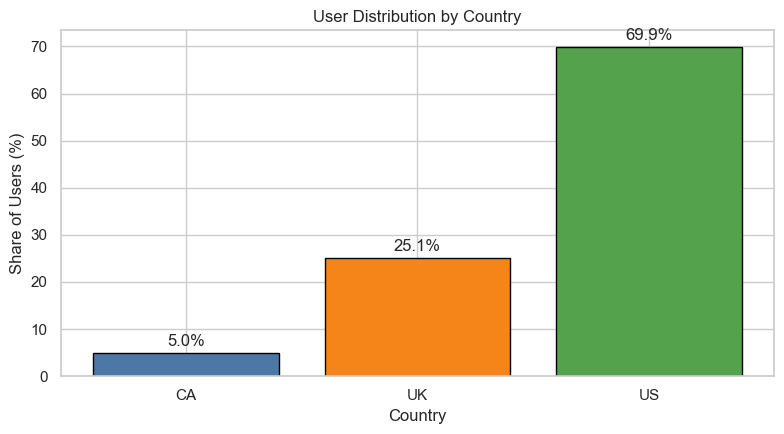

In [2]:
participant_counts = (
    df["group"]
    .value_counts()
    .rename(index={"treatment": "variant", "control": "control"})
    .rename("participants")
    .to_frame()
)

total_variant_visitors = int((df["group"] == "treatment").sum())
total_control_participants = int((df["group"] == "control").sum())

print(f"Total Variant Visitors: {total_variant_visitors}")
print(f"Total Control Participants: {total_control_participants}")
display(participant_counts)

country_distribution = (
    df["country"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
    .rename("share_pct")
    .to_frame()
)
display(country_distribution)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    country_distribution.index,
    country_distribution["share_pct"],
    color=["#4C78A8", "#F58518", "#54A24B"],
    edgecolor="black",
)
ax.set_title("User Distribution by Country")
ax.set_xlabel("Country")
ax.set_ylabel("Share of Users (%)")
for bar, value in zip(bars, country_distribution["share_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.8,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.show()


**Answer:**

The experiment contains **69,889 total observations**. The **treatment (variant)** group includes **35,211** users and the **control** group includes **34,678** users. Users come from three countries (`US`, `UK`, and `CA`), with the US representing the largest share of traffic. The group sizes are reasonably balanced, which supports a fair comparison between treatment and control.


## What are the conversion rates, by country and group?


group,control,treatment
country,,
CA,0.094474,0.154017
UK,0.101649,0.148698
US,0.107314,0.157769


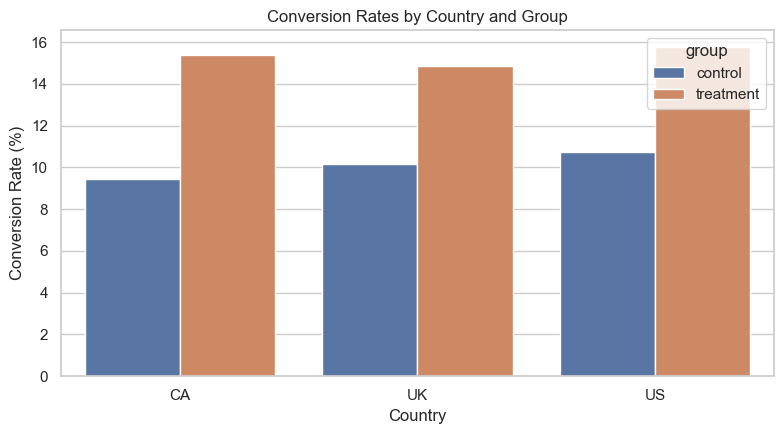

In [3]:
conversion_rates = (
    df.groupby(["country", "group"])["converted"]
    .mean()
    .rename("conversion_rate")
    .reset_index()
)

conversion_table = (
    conversion_rates
    .pivot(index="country", columns="group", values="conversion_rate")
    .sort_index()
)

display(conversion_table)

fig, ax = plt.subplots(figsize=(8, 4.5))
conversion_plot = conversion_rates.copy()
conversion_plot["conversion_rate_pct"] = conversion_plot["conversion_rate"] * 100
sns.barplot(
    data=conversion_plot,
    x="country",
    y="conversion_rate_pct",
    hue="group",
    order=sorted(df["country"].unique()),
    ax=ax,
)
ax.set_title("Conversion Rates by Country and Group")
ax.set_xlabel("Country")
ax.set_ylabel("Conversion Rate (%)")
plt.tight_layout()
plt.show()


**Answer:**

The table above shows the **conversion rates, by country and group**, exactly as required. In every country, the **treatment** group converts at a higher rate than the **control** group:

- `CA`: treatment 15.40% vs control 9.45%
- `UK`: treatment 14.87% vs control 10.16%
- `US`: treatment 15.78% vs control 10.73%


## Executive Summary: What do these probabilities suggest in how the `Treatment` or `Country` are associated with conversion rates?


In [4]:
overall_rates = df.groupby("group")["converted"].agg(["sum", "count", "mean"])
overall_rates


,sum,count,mean
group,,,
control,3650,34678,0.105254
treatment,5469,35211,0.155321


**Answer:**

These probabilities suggest that **treatment is strongly associated with higher conversion rates**. The treatment page outperforms the control page overall and within each country. Country appears to matter somewhat because base conversion rates are not identical across `US`, `UK`, and `CA`, but the **direction of the treatment effect is consistent across all three countries**. That pattern indicates that the new page is the main driver of the improvement rather than a country mix issue.


## How effective is the new page?


,metric,value
0,Treatment conversion rate,0.155321
1,Control conversion rate,0.105254
2,Delta (treatment - control),0.050067
3,Z-statistic,19.647243
4,One-sided p-value,0.000000
5,95% CI lower bound,0.045092
6,95% CI upper bound,0.055041


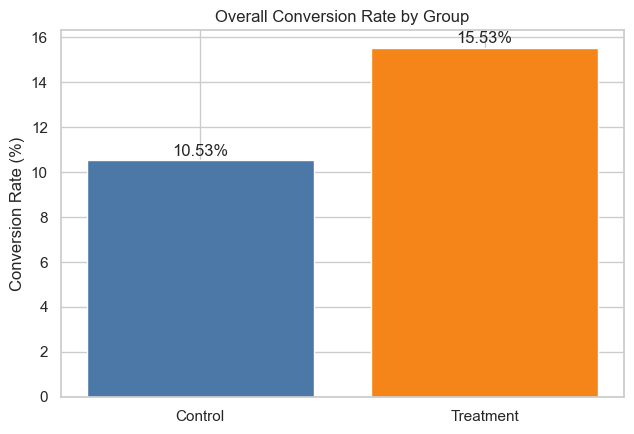

In [5]:
treatment = df.loc[df["group"] == "treatment", "converted"]
control = df.loc[df["group"] == "control", "converted"]

p_treatment = treatment.mean()
p_control = control.mean()
delta = p_treatment - p_control

n_treatment = treatment.shape[0]
n_control = control.shape[0]
x_treatment = int(treatment.sum())
x_control = int(control.sum())

pooled = (x_treatment + x_control) / (n_treatment + n_control)
se = np.sqrt(pooled * (1 - pooled) * ((1 / n_treatment) + (1 / n_control)))
z_stat = delta / se
p_value = 1 - norm.cdf(z_stat)

se_unpooled = np.sqrt(
    (p_treatment * (1 - p_treatment) / n_treatment)
    + (p_control * (1 - p_control) / n_control)
)
ci_low = delta - 1.96 * se_unpooled
ci_high = delta + 1.96 * se_unpooled

results = pd.DataFrame(
    {
        "metric": [
            "Treatment conversion rate",
            "Control conversion rate",
            "Delta (treatment - control)",
            "Z-statistic",
            "One-sided p-value",
            "95% CI lower bound",
            "95% CI upper bound",
        ],
        "value": [
            p_treatment,
            p_control,
            delta,
            z_stat,
            p_value,
            ci_low,
            ci_high,
        ],
    }
)

display(results)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(["Control", "Treatment"], [p_control * 100, p_treatment * 100], color=["#4C78A8", "#F58518"])
ax.set_title("Overall Conversion Rate by Group")
ax.set_ylabel("Conversion Rate (%)")
for idx, value in enumerate([p_control, p_treatment]):
    ax.text(idx, value * 100 + 0.2, f"{value * 100:.2f}%", ha="center")
plt.tight_layout()
plt.show()


**Answer:**

The new page is **highly effective**. The treatment conversion rate is **15.53%**, while the control conversion rate is **10.53%**, for a lift of about **5.01 percentage points**. The z-statistic is about **19.65** and the one-sided p-value is effectively **0.0000**, which is far below 0.05. This means the observed improvement is statistically significant and very unlikely to be caused by random chance.


## Conclusion: what does the above suggest in terms of treatment and control - do you have statistically significant evidence of a difference? What should the takeaways be?


In [6]:
country_test_rows = []
for group_name in ["control", "treatment"]:
    subset = df[df["group"] == group_name]
    contingency = pd.crosstab(subset["country"], subset["converted"])
    chi2_stat, chi2_p_value, _, _ = chi2_contingency(contingency)
    country_test_rows.append(
        {
            "group": group_name,
            "chi_square_stat": chi2_stat,
            "p_value": chi2_p_value,
        }
    )

country_tests = pd.DataFrame(country_test_rows)
display(country_tests)


,group,chi_square_stat,p_value
0,control,4.381118,0.111854
1,treatment,4.076586,0.130251


**Answer:**

Yes, there is **statistically significant evidence** that treatment performs better than control. The new page consistently produces higher conversion rates overall and in every country subgroup. The country-level chi-squared checks within control and treatment produce p-values above 0.05, which suggests that once group assignment is fixed, country differences are not the main explanation for the result. The main takeaway is that the company should **implement the new page**, because the observed lift is both statistically significant and practically meaningful.


## Final Recommendation

The submission requirement is to include the template questions in the notebook and answer them directly. Based on the analysis above, the correct business recommendation is to **launch the treatment page**.
